# Improved UST‑TSG — Transformer‑based Traffic Scene Embeddings for Distributed Risk Prediction

This notebook is a drop‑in research harness that **re‑uses the original `Traffic_Semantic_Graphs` code** (imported from the cloned repository) and **replaces only the pieces that change** in order to push the risk‑prediction performance higher.

**What it keeps from the original repo (imported, unchanged):**
`get_graph_dataset`, `QuantileFeatureQuantizer`, `DiscreteFeatureEncoder`, `batched_graph_embeddings`, `RiskPredictionHead`, `set_seed`, `seed_worker`, `risk_to_class_safe`, `resolve_paths`, `classification_metrics_from_cm`, `_format_confusion_matrix`, `ProjectionHead`, `PairedAnchorDataset`, `_paired_alignment_loss`, `_paired_consistency_loss`.

**What it changes (written in full below):**
1. **Encoder → graph transformer.** The original encoder is a single `HeteroConv(SAGEConv)` layer (mean aggregation, *no attention*) trained as a frozen autoencoder. We replace it with a **multi‑layer heterogeneous graph‑transformer encoder** with multi‑head attention, residual + LayerNorm blocks, per‑type embeddings, and a **typed attention read‑out**. Two transformer back‑ends are provided:
   * `transformerconv` — Graph‑Transformer message passing (UniMP, Shi et al., 2021) inside `HeteroConv`. **Default**, robust to the sparse ego‑centric relation set.
   * `hgt` — **Heterogeneous Graph Transformer** (Hu et al., WWW 2020): meta‑relation typed multi‑head attention. This is exactly the *"typed message passing and attention over relation types"* the paper describes. (Experimental here: needs all relations materialised — handled automatically.)
2. **End‑to‑end training** of encoder + risk head (the repo's frozen‑AE step removed the encoder from the supervised signal). This matches the repo's optional *joint* mode but with the stronger backbone.
3. **Class‑imbalance handling** (inverse‑frequency weighted CE / optional focal loss / label smoothing). The risk distribution is heavily skewed, so this directly lifts minority (high‑risk) recall — the safety‑critical classes.
4. **Cosine LR schedule with linear warm‑up**, AdamW, gradient clipping.
5. **Training with patience, best+final checkpointing**, full train/val curve logging.
6. **Richer, ordinal‑aware evaluation** (accuracy, balanced accuracy, macro‑F1, per‑class P/R/F1, quadratic‑weighted‑kappa, ordinal MAE, confusion matrices).
7. **Config‑addressed output tree** under `Resultsandweights/` — every distinct configuration writes to its **own** sub‑folder (readable hyper‑params + a short config hash), so changing parameters **never overwrites** previous runs. Results are saved both as **`.mat`** (for MATLAB figures / further analysis) and as a plain‑text **report** (for downstream reading).
8. **Two run modes:** `train_eval` (train then evaluate) and `eval_only` (load the best checkpoint for this exact config and evaluate).

**Transformer references (Stefano's suggestion) — usable in the paper:**
- A. Vaswani et al., *Attention Is All You Need*, NeurIPS 2017.
- Z. Hu, Y. Dong, K. Wang, Y. Sun, *Heterogeneous Graph Transformer (HGT)*, WWW 2020 — typed Q/K/V projections, meta‑relation attention, relative temporal encoding (RTE).
- X. Jia, P. Wu, L. Chen, Y. Liu, H. Li, J. Yan, *HDGT: Heterogeneous Driving Graph Transformer*, IEEE TPAMI 2023 — ego‑centric heterogeneous driving‑scene graph transformer (this is ref [5] in the manuscript).
- Y. Shi et al., *Masked Label Prediction: Unified Message Passing Model (UniMP / TransformerConv)*, IJCAI 2021.
- S. Brody, U. Alon, E. Yahav, *How Attentive are Graph Attention Networks? (GATv2)*, ICLR 2022.

> **The full method/architecture is selected by the `Config` block in the next code cells — read that first, set the paths, then run top‑to‑bottom.**


In [19]:
# =====================================================================
# 0. Imports + path to the cloned repository
# =====================================================================
import os, sys, json, math, time, hashlib, random, platform, re
import subprocess, shutil
from pathlib import Path
from dataclasses import dataclass, field, asdict
from typing import Optional, List, Dict, Any, Tuple, Callable

# Select the GPU BEFORE importing torch (so CUDA initialises on the chosen device).
# Respects an externally-set CUDA_VISIBLE_DEVICES; defaults to "0" otherwise.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim.lr_scheduler import LambdaLR

# ---- POINT THIS AT YOUR CLONED REPO ROOT (the folder that contains `src/`) ----
# Examples:
#   REPO_ROOT = "/home/me/Traffic_Semantic_Graphs"
#   REPO_ROOT = r"C:\\Users\\me\\Traffic_Semantic_Graphs"
REPO_ROOT = os.environ.get("TSG_REPO_ROOT", os.path.abspath("."))

assert os.path.isdir(os.path.join(REPO_ROOT, "src")), (
    f"Could not find `src/` under REPO_ROOT={REPO_ROOT!r}. "
    "Set REPO_ROOT to the cloned Traffic_Semantic_Graphs directory."
)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

# PyTorch Geometric (installed in your `sem_graphs` environment)
from torch_geometric.loader import DataLoader as PygDataLoader
from torch_geometric.nn import HeteroConv, TransformerConv, GATv2Conv, global_add_pool
try:
    from torch_geometric.nn import HGTConv
    _HAS_HGT = True
except Exception:
    _HAS_HGT = False
from torch_geometric.utils import softmax as geo_softmax

# ---- Imports from the ORIGINAL repo (UNCHANGED) ----
from src.graph_encoding.data_loaders import get_graph_dataset
from src.graph_encoding.autoencoder import (
    QuantileFeatureQuantizer,
    DiscreteFeatureEncoder,
    batched_graph_embeddings,          # kept for the optional "mean" read-out (apples-to-apples ablation)
)
from src.graph_encoding.risk_prediction import RiskPredictionHead
from src.experiment_utils import (
    set_seed,
    seed_worker,
    risk_to_class_safe,                # 4-class risk binning used by the paper
    resolve_paths,                     # builds train/eval graph + risk-score paths
    classification_metrics_from_cm,
    confusion_matrix,                  # K×K integer confusion matrix
    ordinal_mae,                       # ordinal (distance) error between class indices
    quadratic_weighted_kappa,          # QWK — ordinal agreement metric
    _format_confusion_matrix,
    ProjectionHead,                    # same-dim residual projection head (UST student)
    PairedAnchorDataset,               # pairs clean/noisy items by episode stem
    _paired_alignment_loss,
    _paired_consistency_loss,
)

from scipy.io import savemat

print("Repo:", REPO_ROOT)
print("torch:", torch.__version__, "| HGTConv available:", _HAS_HGT)


Repo: f:\NYCU\nuplan_clean\Traffic_Semantic_Graphs
torch: 2.5.1+cu124 | HGTConv available: True


In [20]:
# =====================================================================
# 1. Configuration  -- EVERYTHING THAT DEFINES A RUN LIVES HERE
#    Changing any field routes outputs to a NEW sub-folder (no overwrites).
# =====================================================================
@dataclass
class Config:
    # ---- run control ----
    run_mode: str = "train_eval"          # "train_eval" | "eval_only"
    method:   str = "ust"                 # "supervised" | "ust"
    seed:     int = 42
    device:   str = "cuda" if torch.cuda.is_available() else "cpu"

    # ---- dataset (NuPlan) ----
    dataset_src:   str = "nup"            # "nup" | "l2d"   (controls data_root)
    data_root:     str = ""               # auto-filled in next cell if left ""
    dataset_clean: str = "clean"          # high-quality / teacher domain
    dataset_noisy: str = "noisy_10"       # degraded / student domain ("none" disables)
    graph_mode:    str = "all"            # dataset variant: all / ego_veh / ego / ego_env (+ *_no_edges)
    val_fraction:  float = 0.2
    num_workers:   int = 0

    # ---- task ----
    prediction_mode: str = "classification"   # this notebook implements classification (paper's headline)
    num_classes:     int = 4

    # ---- feature quantiser (kept from repo; bins -> per-feature embeddings) ----
    quant_bins:   int = 32
    feat_emb_dim: int = 16

    # ---- encoder (the transformer upgrade) ----
    encoder_type: str = "transformerconv"  # "transformerconv" | "gatv2" | "hgt"
    hidden_dim:   int = 128
    embed_dim:    int = 64                  # per-node-type latent; graph emb dim = num_node_types * embed_dim
    num_layers:   int = 3
    heads:        int = 4
    dropout:      float = 0.1
    readout:      str = "attention"         # "attention" (typed attention pooling) | "mean" (repo concat-mean)
    use_type_emb: bool = True

    # ---- risk head ----
    risk_hidden_dim: int = 128
    risk_dropout:    float = 0.3

    # ---- optimisation ----
    epochs:        int = 40
    batch_size:    int = 16
    lr:            float = 3e-4
    weight_decay:  float = 1e-4
    warmup_ratio:  float = 0.05            # fraction of total steps used for linear warm-up
    min_lr_ratio:  float = 0.02            # cosine floor as a fraction of base lr
    grad_clip:     float = 1.0
    patience:      int = 8                 # early-stop patience (epochs without monitor improvement)
    monitor_metric: str = "accuracy"       # "accuracy"|"balanced_accuracy"|"macro_f1"|"qwk"
    monitor_mode:   str = "max"

    # ---- loss / imbalance ----
    loss_kind:        str = "ce"           # "ce" | "focal"
    use_class_weights: bool = True
    label_smoothing:  float = 0.0          # used only by ce
    focal_gamma:      float = 2.0          # used only by focal

    # ---- UST alignment stage (method == "ust") ----
    run_alignment:   bool = True
    anchor_frac:     float = 1.0           # fraction of paired (clean,noisy) episodes used as anchors
    align_epochs:    int = 30
    align_lr:        float = 3e-4
    align_weight:    float = 1.0           # weight on embedding-alignment loss
    align_loss_kind: str = "l2"            # "l2" | "smoothl1" | "cosine"
    kd_weight:       float = 0.5           # weight on risk-head consistency (distillation) loss
    kd_kind:         str = "kl"            # "kl" | "mse"
    proj_l2_normalize: bool = False
    warm_start_noisy_from_clean: bool = True

    # ---- supervised-only cross-domain probe (method == "supervised") ----
    eval_cross_noisy: bool = False         # also evaluate the clean-trained model on the noisy eval set

    # ---- output ----
    results_root: str = "Resultsandweights"

CFG = Config()
print(json.dumps(asdict(CFG), indent=2))


{
  "run_mode": "train_eval",
  "method": "ust",
  "seed": 42,
  "device": "cuda",
  "dataset_src": "nup",
  "data_root": "",
  "dataset_clean": "clean",
  "dataset_noisy": "noisy_10",
  "graph_mode": "all",
  "val_fraction": 0.2,
  "num_workers": 0,
  "prediction_mode": "classification",
  "num_classes": 4,
  "quant_bins": 32,
  "feat_emb_dim": 16,
  "encoder_type": "transformerconv",
  "hidden_dim": 128,
  "embed_dim": 64,
  "num_layers": 3,
  "heads": 4,
  "dropout": 0.1,
  "readout": "attention",
  "use_type_emb": true,
  "risk_hidden_dim": 128,
  "risk_dropout": 0.3,
  "epochs": 40,
  "batch_size": 16,
  "lr": 0.0003,
  "weight_decay": 0.0001,
  "warmup_ratio": 0.05,
  "min_lr_ratio": 0.02,
  "grad_clip": 1.0,
  "patience": 8,
  "monitor_metric": "accuracy",
  "monitor_mode": "max",
  "loss_kind": "ce",
  "use_class_weights": true,
  "label_smoothing": 0.0,
  "focal_gamma": 2.0,
  "run_alignment": true,
  "anchor_frac": 1.0,
  "align_epochs": 30,
  "align_lr": 0.0003,
  "align_wei

In [21]:
# =====================================================================
# 2. Reproducibility, device, data_root
# =====================================================================
set_seed(CFG.seed)
DEVICE = torch.device(CFG.device)

if not CFG.data_root:
    CFG.data_root = os.path.abspath(
        os.path.join(REPO_ROOT, "data", "NuPlan" if CFG.dataset_src == "nup" else "L2D")
    )
print("device   :", DEVICE)
print("data_root:", CFG.data_root)

# A tiny shim so we can reuse the repo's resolve_paths(args_like, name)
class _PathArgs:
    def __init__(self, data_root): self.data_root = data_root
PATH_ARGS = _PathArgs(CFG.data_root)


device   : cuda
data_root: f:\NYCU\nuplan_clean\Traffic_Semantic_Graphs\data\NuPlan


In [22]:
# =====================================================================
# 3. Config-addressed run directory under Resultsandweights/
#    -> readable hyper-params + short hash; distinct config = distinct folder.
# =====================================================================
def _short_hash(cfg: Config) -> str:
    payload = json.dumps(asdict(cfg), sort_keys=True).encode("utf-8")
    return hashlib.sha1(payload).hexdigest()[:8]

def make_run_dir(cfg: Config) -> str:
    noisy = cfg.dataset_noisy if (cfg.method == "ust" and cfg.dataset_noisy != "none") else "none"
    arch = (f"{cfg.encoder_type}_h{cfg.hidden_dim}_e{cfg.embed_dim}"
            f"_L{cfg.num_layers}_H{cfg.heads}_{cfg.readout}")
    train = (f"lr{cfg.lr:g}_bs{cfg.batch_size}_wd{cfg.weight_decay:g}_do{cfg.dropout:g}"
             f"_{cfg.loss_kind}_cw{int(cfg.use_class_weights)}")
    if cfg.method == "ust":
        train += f"_aw{cfg.align_weight:g}_{cfg.align_loss_kind}_kd{cfg.kd_weight:g}_anc{cfg.anchor_frac:g}"
    train += f"_seed{cfg.seed}_{_short_hash(cfg)}"
    run_dir = os.path.join(
        os.path.abspath(os.path.join(REPO_ROOT, cfg.results_root)),
        cfg.method,
        f"{cfg.dataset_clean}__vs__{noisy}",
        cfg.prediction_mode,
        arch,
        train,
    )
    return run_dir

RUN_DIR = make_run_dir(CFG)
os.makedirs(RUN_DIR, exist_ok=True)
BEST_CKPT  = os.path.join(RUN_DIR, "best_model.pt")
FINAL_CKPT = os.path.join(RUN_DIR, "final_model.pt")
print("RUN_DIR:", RUN_DIR)


RUN_DIR: f:\NYCU\nuplan_clean\Traffic_Semantic_Graphs\Resultsandweights\ust\clean__vs__noisy_10\classification\transformerconv_h128_e64_L3_H4_attention\lr0.0003_bs16_wd0.0001_do0.1_ce_cw1_aw1_l2_kd0.5_anc1_seed42_4ddcd358


In [23]:
# =====================================================================
# 4. Data: per-domain dataset + quantiser + deterministic split + loaders
# =====================================================================
def _loader_kwargs(cfg: Config, shuffle: bool):
    gen = torch.Generator().manual_seed(cfg.seed)
    kw = dict(batch_size=cfg.batch_size, shuffle=shuffle,
              num_workers=cfg.num_workers,
              worker_init_fn=seed_worker if cfg.num_workers > 0 else None,
              generator=gen,
              pin_memory=torch.cuda.is_available())
    if cfg.num_workers > 0:
        kw["persistent_workers"] = True
    return kw

def split_indices(n: int, val_fraction: float, seed: int):
    val_size = int(val_fraction * n)
    g = torch.Generator().manual_seed(seed)
    perm = torch.randperm(n, generator=g).tolist()
    val_idx = perm[:val_size]
    train_idx = perm[val_size:]
    return train_idx, val_idx

def load_domain(cfg: Config, dataset_name: str, split: str = "train"):
    """Return (dataset, paths_dict) for a domain. split in {'train','eval'}."""
    paths = resolve_paths(PATH_ARGS, dataset_name)
    if split == "train":
        groot, rpath = paths["train_graph_root"], paths["train_risk_path"]
    else:
        groot, rpath = paths["eval_graph_root"], paths["eval_risk_path"]
    assert os.path.isdir(groot), f"Graphs not found: {groot}"
    assert os.path.isfile(rpath), f"Risk scores not found: {rpath}"
    ds = get_graph_dataset(root_dir=groot, mode=cfg.graph_mode,
                           side_information_path=None, risk_scores_path=rpath)
    return ds, paths

def fit_quantizer(cfg: Config, dataset):
    q = QuantileFeatureQuantizer(bins=cfg.quant_bins, node_types=dataset.get_metadata()[0])
    q.fit(dataset)
    return q

print("[data] data helpers ready")


[data] data helpers ready


## Model — heterogeneous graph **transformer** encoder + typed attention read‑out

The encoder reuses the repo's discrete‑feature embedding (`DiscreteFeatureEncoder`: each quantised feature → learned embedding) for the input layer, then runs **`num_layers` transformer blocks** with residual + LayerNorm. A learnable **type embedding** is added per node type. The read‑out is a **typed attention pooling**: within each graph, per‑type node embeddings are softmax‑weighted and summed, then concatenated across the four node types — giving a graph embedding of size `num_node_types × embed_dim` (same dimensionality as the repo's mean‑pool concat, so the risk head and the UST projection are directly comparable).

In [24]:
# =====================================================================
# 5. Class-imbalance weights (scanned once over the training loader)
# =====================================================================
@torch.no_grad()
def compute_class_weights(loader, num_classes: int) -> Tuple[torch.Tensor, np.ndarray]:
    counts = np.zeros(num_classes, dtype=np.int64)
    for batch in loader:
        y_cls = risk_to_class_safe(batch.y).cpu().numpy()
        for c in y_cls:
            if 0 <= int(c) < num_classes:
                counts[int(c)] += 1
    total = max(int(counts.sum()), 1)
    # inverse-frequency, normalised so mean weight == 1
    freq = np.where(counts > 0, counts, 1).astype(np.float64)
    w = total / (num_classes * freq)
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32), counts

print("[utils] class-weight helper ready")


[utils] class-weight helper ready


In [25]:
# =====================================================================
# 6. MODEL: typed attention read-out + transformer encoder  (REWRITTEN)
# =====================================================================
def _make_conv(cfg: Config, node_types, edge_types):
    """One heterogeneous message-passing layer that outputs `hidden_dim` per type."""
    h, heads = cfg.hidden_dim, cfg.heads
    assert h % heads == 0, "hidden_dim must be divisible by heads"
    if cfg.encoder_type == "hgt":
        assert _HAS_HGT, "HGTConv not available in this torch_geometric build."
        return ("hgt", HGTConv(h, h, (list(node_types), list(edge_types)), heads=heads))
    if cfg.encoder_type == "gatv2":
        convs = {et: GATv2Conv(h, h // heads, heads=heads, concat=True,
                               dropout=cfg.dropout, add_self_loops=False)
                 for et in edge_types}
        return ("hetero", HeteroConv(convs, aggr="sum"))
    # default: graph-transformer message passing (UniMP / TransformerConv)
    convs = {et: TransformerConv(h, h // heads, heads=heads, concat=True,
                                 dropout=cfg.dropout, beta=False)
             for et in edge_types}
    return ("hetero", HeteroConv(convs, aggr="sum"))


class TypedAttentionReadout(nn.Module):
    """Per-type softmax-attention pooling -> concat across node types -> [B, T*embed_dim]."""
    def __init__(self, node_types, embed_dim):
        super().__init__()
        self.node_types = list(node_types)
        self.embed_dim = embed_dim
        self.score = nn.ModuleDict({nt: nn.Linear(embed_dim, 1) for nt in self.node_types})

    def forward(self, z_dict, data, num_graphs, device):
        blocks = []
        for nt in self.node_types:
            has = (nt in z_dict and z_dict[nt].numel() > 0
                   and nt in data.node_types and "batch" in data[nt])
            if has:
                z = z_dict[nt]
                b = data[nt].batch
                a = geo_softmax(self.score[nt](z), b, num_nodes=num_graphs)   # softmax within each graph
                pooled = global_add_pool(a * z, b, size=num_graphs)          # [B, embed_dim]
            else:
                pooled = torch.zeros(num_graphs, self.embed_dim, device=device)
            if pooled.size(0) < num_graphs:
                pad = torch.zeros(num_graphs - pooled.size(0), self.embed_dim, device=device)
                pooled = torch.cat([pooled, pad], dim=0)
            blocks.append(pooled)
        return torch.cat(blocks, dim=-1)


class HeteroGraphTransformer(nn.Module):
    """Transformer encoder over the heterogeneous (ego-centric) traffic scene graph."""
    def __init__(self, cfg: Config, metadata, quantizer_spec):
        super().__init__()
        self.cfg = cfg
        self.node_types, self.edge_types = metadata
        self.metadata = metadata
        self.embed_dim = cfg.embed_dim
        self.graph_emb_dim = len(self.node_types) * cfg.embed_dim
        self.act = F.gelu

        # input featurisation (reuse repo's per-feature embedding table)
        self.feature_encoder = DiscreteFeatureEncoder(quantizer_spec, embed_dim=cfg.feat_emb_dim)
        self.pre = nn.ModuleDict()
        for nt in self.node_types:
            in_dim = self.feature_encoder.in_dims.get(nt, 0)
            self.pre[nt] = nn.Linear(in_dim if in_dim > 0 else 1, cfg.hidden_dim)

        self.use_type_emb = cfg.use_type_emb
        if self.use_type_emb:
            self.type_emb = nn.Embedding(len(self.node_types), cfg.hidden_dim)
            self.type_index = {nt: i for i, nt in enumerate(self.node_types)}
        self.in_norm = nn.ModuleDict({nt: nn.LayerNorm(cfg.hidden_dim) for nt in self.node_types})

        # transformer blocks
        self.kinds, self.layers, self.norms = [], nn.ModuleList(), nn.ModuleList()
        for _ in range(cfg.num_layers):
            kind, conv = _make_conv(cfg, self.node_types, self.edge_types)
            self.kinds.append(kind)
            self.layers.append(conv)
            self.norms.append(nn.ModuleDict({nt: nn.LayerNorm(cfg.hidden_dim) for nt in self.node_types}))
        self.drop = nn.Dropout(cfg.dropout)
        self.out_proj = nn.ModuleDict({nt: nn.Linear(cfg.hidden_dim, cfg.embed_dim) for nt in self.node_types})

        self.readout_kind = cfg.readout
        if cfg.readout == "attention":
            self.readout = TypedAttentionReadout(self.node_types, cfg.embed_dim)

    # ---- helpers ----
    def _build_inputs(self, data, device):
        emb = self.feature_encoder(data)                  # dict nt -> [N, F*feat_emb_dim]
        x = {}
        for nt in self.node_types:
            if nt in emb and emb[nt].numel() > 0:
                h = self.pre[nt](emb[nt])
            else:
                n = data[nt].x.size(0) if (nt in data.node_types and "x" in data[nt]) else 0
                h = torch.zeros(n, self.cfg.hidden_dim, device=device)
            if self.use_type_emb and h.size(0) > 0:
                h = h + self.type_emb.weight[self.type_index[nt]].unsqueeze(0)
            x[nt] = self.in_norm[nt](h) if h.size(0) > 0 else h
        return x

    def _ensure_all_relations(self, data):
        """HGTConv indexes every metadata relation; materialise missing ones as empty."""
        for et in self.edge_types:
            if et not in data.edge_index_dict:
                data[et].edge_index = torch.empty(2, 0, dtype=torch.long, device=data[et[0]].x.device
                                                   if (et[0] in data.node_types and "x" in data[et[0]]) else None)
        return data

    def forward(self, data):
        device = next(self.parameters()).device
        if self.cfg.encoder_type == "hgt":
            data = self._ensure_all_relations(data)
        x = self._build_inputs(data, device)
        edge_index_dict = data.edge_index_dict
        h = x
        for kind, conv, norm in zip(self.kinds, self.layers, self.norms):
            out = conv(h, edge_index_dict)
            new_h = {}
            for nt in self.node_types:
                if nt in out and out[nt].numel() > 0 and nt in h and h[nt].shape == out[nt].shape:
                    u = self.drop(self.act(out[nt]))
                    new_h[nt] = norm[nt](h[nt] + u)            # residual + LayerNorm (transformer block)
                elif nt in out and out[nt].numel() > 0:
                    new_h[nt] = norm[nt](self.drop(self.act(out[nt])))
                else:
                    new_h[nt] = h.get(nt, x.get(nt))            # unchanged if no messages
            h = new_h
        z = {nt: self.out_proj[nt](h[nt]) for nt in self.node_types
             if nt in h and h[nt] is not None and h[nt].numel() > 0}
        return z

    def graph_embedding(self, data):
        device = next(self.parameters()).device
        z = self.forward(data)
        if self.readout_kind == "attention":
            return self.readout(z, data, data.num_graphs, device)
        # repo-compatible concat-of-means read-out (ablation)
        return batched_graph_embeddings(z, data, self.metadata, pooling="mean",
                                        embed_dim_per_type=self.embed_dim)

print("[model] HeteroGraphTransformer defined")


[model] HeteroGraphTransformer defined


In [26]:
# =====================================================================
# 7. Losses: weighted CE / focal (+ optional label smoothing)
# =====================================================================
class FocalCE(nn.Module):
    def __init__(self, gamma=2.0, weight=None):
        super().__init__()
        self.gamma = gamma
        self.register_buffer("weight", weight if weight is not None else None)
    def forward(self, logits, target):
        logp = F.log_softmax(logits, dim=-1)
        ce = F.nll_loss(logp, target, weight=self.weight, reduction="none")
        pt = logp.gather(1, target.view(-1, 1)).squeeze(1).exp()
        return ((1.0 - pt) ** self.gamma * ce).mean()

def build_risk_criterion(cfg: Config, class_weight: Optional[torch.Tensor]):
    w = class_weight.to(DEVICE) if (cfg.use_class_weights and class_weight is not None) else None
    if cfg.loss_kind == "focal":
        return FocalCE(gamma=cfg.focal_gamma, weight=w)
    return nn.CrossEntropyLoss(weight=w, label_smoothing=cfg.label_smoothing)

print("[loss] criterion builder ready")


[loss] criterion builder ready


In [27]:
# =====================================================================
# 8. Optimiser (AdamW) + cosine schedule with linear warm-up  (my fav)
# =====================================================================
def build_optimizer(params, lr: float, weight_decay: float):
    return torch.optim.AdamW([p for p in params if p.requires_grad],
                             lr=lr, weight_decay=weight_decay)

def cosine_warmup_scheduler(optimizer, total_steps: int, warmup_ratio: float, min_lr_ratio: float):
    warmup_steps = max(1, int(warmup_ratio * total_steps))
    def lr_lambda(step):
        if step < warmup_steps:
            return step / float(warmup_steps)
        progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
        cos = 0.5 * (1.0 + math.cos(math.pi * min(1.0, progress)))
        return min_lr_ratio + (1.0 - min_lr_ratio) * cos
    return LambdaLR(optimizer, lr_lambda)

print("[optim] AdamW + cosine-warmup scheduler ready")


[optim] AdamW + cosine-warmup scheduler ready


## Evaluation, checkpointing, training and the run harness

The pieces below are written in full (they replace the repo's frozen‑AE training loop and its CSV logging):

* **`evaluate`** — runs a loader through *encoder → (optional projection) → risk head*, then reports **accuracy, balanced accuracy, macro‑F1, macro‑precision/recall, quadratic‑weighted‑kappa, ordinal‑MAE**, a full **confusion matrix** and **per‑class P/R/F1** (reusing the repo's `confusion_matrix`, `classification_metrics_from_cm`, `quadratic_weighted_kappa`, `ordinal_mae`).
* **`train_supervised`** — end‑to‑end training of encoder (+ projection for the UST teacher) + risk head, with **AdamW + cosine‑warm‑up**, gradient clipping, **early‑stopping on the monitored metric**, and **best + final** checkpoints; logs the full train/val curve.
* **`train_alignment`** — the **UST** student stage: a noisy‑domain encoder + projection are aligned to the frozen clean teacher in a shared embedding space (`_paired_alignment_loss`) with a **knowledge‑distillation** term through the frozen risk head (`_paired_consistency_loss`); monitored by **noisy‑validation accuracy**.
* **Persistence** — every run writes a **`.mat`** file (for MATLAB figures) **and** a plain‑text report, both under the config‑addressed `Resultsandweights/` sub‑folder.
* **Run harness** — honours `run_mode` (`train_eval` / `eval_only`) and `method` (`supervised` / `ust`).

In [28]:
# =====================================================================
# 9. Evaluation (ordinal-aware) + a single forward helper
# =====================================================================
def _forward_logits(batch, quant, encoder, head, proj=None):
    """Quantise -> encode -> (optional projection) -> risk logits. Returns (logits, y_class)."""
    batch = quant.transform_inplace(batch).to(DEVICE)
    emb = encoder.graph_embedding(batch)
    if proj is not None:
        emb = proj(emb)
    logits = head(emb)
    y = risk_to_class_safe(batch.y).to(DEVICE).view(-1)
    return logits, y


def _per_class_prf(cm):
    cm = np.asarray(cm, dtype=np.float64)
    tp = np.diag(cm)
    support = cm.sum(axis=1)
    pred = cm.sum(axis=0)
    prec = np.divide(tp, pred, out=np.zeros_like(tp), where=pred > 0)
    rec = np.divide(tp, support, out=np.zeros_like(tp), where=support > 0)
    denom = prec + rec
    f1 = np.divide(2 * prec * rec, denom, out=np.zeros_like(tp), where=denom > 0)
    return {"precision": prec, "recall": rec, "f1": f1, "support": support.astype(np.int64)}


@torch.no_grad()
def evaluate(encoder, head, quant, loader, cfg, proj=None, criterion=None):
    was_e, was_h = encoder.training, head.training
    was_p = proj.training if proj is not None else None
    encoder.eval(); head.eval()
    if proj is not None: proj.eval()

    ys, ps, lg = [], [], []
    loss_sum, nb = 0.0, 0
    for batch in loader:
        logits, y = _forward_logits(batch, quant, encoder, head, proj)
        if criterion is not None and y.numel() > 0:
            loss_sum += float(criterion(logits, y).item()); nb += 1
        ps.append(logits.argmax(dim=-1).cpu().numpy())
        ys.append(y.cpu().numpy())
        lg.append(logits.detach().cpu().numpy())

    y_true = np.concatenate(ys) if ys else np.zeros(0, np.int64)
    y_pred = np.concatenate(ps) if ps else np.zeros(0, np.int64)
    logits_arr = np.concatenate(lg, axis=0) if lg else np.zeros((0, cfg.num_classes), np.float32)

    cm = confusion_matrix(y_true, y_pred, cfg.num_classes)
    m = classification_metrics_from_cm(cm)
    m["qwk"] = quadratic_weighted_kappa(y_true, y_pred, cfg.num_classes) if len(y_true) else 0.0
    m["ordinal_mae"] = ordinal_mae(y_true, y_pred) if len(y_true) else 0.0

    if was_e: encoder.train()
    if was_h: head.train()
    if proj is not None and was_p: proj.train()

    return {"metrics": m, "cm": np.asarray(cm), "per_class": _per_class_prf(cm),
            "y_true": y_true, "y_pred": y_pred, "logits": logits_arr,
            "loss": (loss_sum / nb if nb else float("nan"))}

print("[eval] evaluate() ready")


[eval] evaluate() ready


In [29]:
# =====================================================================
# 10. Builders + checkpoint (bundle) helpers + lazy-parameter warm-up
# =====================================================================
def build_encoder(cfg: Config, metadata, quant_spec):
    return HeteroGraphTransformer(cfg, metadata, quant_spec).to(DEVICE)

def build_risk_head(cfg: Config, graph_emb_dim: int):
    return RiskPredictionHead(graph_emb_dim, cfg.risk_hidden_dim, cfg.num_classes,
                              mode="classification", dropout_rate=cfg.risk_dropout).to(DEVICE)

def build_proj(cfg: Config, dim: int):
    # same-dim residual projection into the shared embedding space (UST)
    return ProjectionHead(dim, hidden_dim=dim, dropout=cfg.dropout,
                          activation="gelu", residual=True).to(DEVICE)


@torch.no_grad()
def materialize_lazy(encoder, quant, loader):
    """Run ONE batch so PyG lazy conv params (TransformerConv/GATv2 with (-1,-1))
    get initialised. Required before load_state_dict in eval_only / warm-start."""
    encoder.eval()
    for batch in loader:
        b = quant.transform_inplace(batch).to(DEVICE)
        _ = encoder.graph_embedding(b)
        break


def save_bundle(path, modules: Dict[str, nn.Module], cfg: Config, extra: Optional[dict] = None):
    payload = {"config": asdict(cfg),
               "modules": {k: m.state_dict() for k, m in modules.items()}}
    if extra:
        payload["extra"] = extra
    torch.save(payload, path)

def load_bundle(path, modules: Dict[str, nn.Module], strict: bool = True, map_location=None):
    # Torch 1.12 does not support the weights_only keyword; the bundle stores config + metadata.
    ckpt = torch.load(path, map_location=map_location or DEVICE)
    mods = ckpt.get("modules", {})
    for k, m in modules.items():
        if k in mods:
            m.load_state_dict(mods[k], strict=strict)
        else:
            print(f"[warn] module '{k}' not present in checkpoint {os.path.basename(path)}")
    return ckpt

print("[build] builders + checkpoint helpers ready")


[build] builders + checkpoint helpers ready


In [30]:
# =====================================================================
# 11. Persistence: .mat (MATLAB) + plain-text report
#     Distinct config -> distinct RUN_DIR, so nothing is overwritten.
# =====================================================================
def _san_key(k: str) -> str:
    s = re.sub(r"[^0-9A-Za-z_]", "_", str(k))
    if not s:
        s = "field"
    if s[0].isdigit():
        s = "f_" + s
    return s[:31]                      # MATLAB struct field-name length cap

def to_mat_safe(obj):
    """Recursively convert a python/numpy structure into something savemat accepts."""
    if isinstance(obj, dict):
        return {_san_key(k): to_mat_safe(v) for k, v in obj.items()}
    if isinstance(obj, bool):
        return np.int64(1 if obj else 0)
    if isinstance(obj, (int, np.integer)):
        return np.int64(obj)
    if isinstance(obj, (float, np.floating)):
        return np.float64(obj)
    if isinstance(obj, str):
        return obj
    if obj is None:
        return np.array([])
    if isinstance(obj, np.ndarray):
        return obj.astype(np.int64) if obj.dtype == bool else obj
    if isinstance(obj, (list, tuple)):
        if len(obj) == 0:
            return np.array([])
        if all(isinstance(x, bool) for x in obj):
            return np.array([int(x) for x in obj], dtype=np.int64)
        if all(isinstance(x, (int, float, np.integer, np.floating)) for x in obj):
            return np.array(obj)
        if all(isinstance(x, str) for x in obj):
            return np.array(obj, dtype=object)
        return np.array([to_mat_safe(x) for x in obj], dtype=object)
    return str(obj)

def save_mat(path, results: dict):
    savemat(path, {"results": to_mat_safe(results)}, do_compression=True)


def _fmt_metrics(m: dict) -> str:
    order = ["accuracy", "balanced_accuracy", "macro_f1", "macro_precision",
             "macro_recall", "qwk", "ordinal_mae"]
    return "\n".join(f"    {k:<20s}: {float(m[k]):.4f}" for k in order if k in m)

def _fmt_per_class(pc: dict, n: int) -> str:
    lines = ["    class |   prec |    rec |     f1 | support",
             "    ------+--------+--------+--------+--------"]
    for c in range(n):
        lines.append(f"    {c:>5d} | {pc['precision'][c]:.4f} | {pc['recall'][c]:.4f} | "
                     f"{pc['f1'][c]:.4f} | {int(pc['support'][c]):>7d}")
    return "\n".join(lines)

def write_report(path, R: dict):
    cfg = R["config"]
    L = []
    A = L.append
    A("=" * 72)
    A("IMPROVED UST-TSG  --  RISK PREDICTION RESULTS")
    A("=" * 72)
    A(f"run_dir : {R['run_dir']}")
    A(f"method  : {cfg['method']}   |   run_mode: {cfg['run_mode']}   |   encoder: {cfg['encoder_type']}")
    A(f"node_types: {', '.join(R['node_types'])}")
    A("")
    A("-" * 72); A("CONFIGURATION"); A("-" * 72)
    for k in sorted(cfg.keys()):
        A(f"  {k:<30s}: {cfg[k]}")
    A("")
    A("-" * 72); A("DATA"); A("-" * 72)
    for k, v in R["data_sizes"].items():
        A(f"  {k:<30s}: {v}")
    A("")
    A("-" * 72); A("CLASS DISTRIBUTION (clean training split)"); A("-" * 72)
    A(f"  thresholds (risk -> class): {R['class_thresholds']}")
    A(f"  counts  : {list(R['class_counts_train'])}")
    A(f"  weights : {[round(float(x), 4) for x in list(R['class_weights'])]}")
    A("")
    A("-" * 72); A("TRAINING"); A("-" * 72)
    hist = R["history"]
    if not hist:
        A("  (eval_only run -- no training performed)")
    for stage, h in hist.items():
        if not h:
            A(f"  [{stage}] (skipped)"); A(""); continue
        A(f"  [{stage}] monitor={h.get('monitor','?')}  "
          f"best={float(h.get('best_value', float('nan'))):.4f} @ epoch {h.get('best_epoch','?')}")
        tl = h.get("train_loss", []); vl = h.get("val_loss", []); vm = h.get("val_metric", [])
        A(f"    epochs run: {len(tl)}")
        A(f"    {'epoch':>6s} | {'train_loss':>11s} | {'val_loss':>9s} | {'val_metric':>10s}")
        A(f"    -------+-------------+-----------+-----------")
        for i in range(len(tl)):
            vli = vl[i] if i < len(vl) else float("nan")
            vmi = vm[i] if i < len(vm) else float("nan")
            A(f"    {i+1:>6d} | {tl[i]:>11.4f} | {vli:>9.4f} | {vmi:>10.4f}")
        A("")
    A("-" * 72); A("EVALUATION"); A("-" * 72)
    n = int(cfg["num_classes"])
    for dom, ev in R["eval"].items():
        A(f"  === domain: {dom} ===")
        A(_fmt_metrics(ev["metrics"]))
        A("")
        A("  per-class:")
        A(_fmt_per_class(ev["per_class"], n))
        A("")
        A("  confusion matrix (rows=true, cols=pred):")
        for ln in _format_confusion_matrix(np.asarray(ev["confusion_matrix"])).splitlines():
            A("    " + ln)
        A("")
    A("-" * 72); A("NOTES"); A("-" * 72)
    A("  Encoder: multi-layer heterogeneous graph transformer (multi-head attention,")
    A("  residual + LayerNorm blocks, per-type embeddings, typed attention read-out),")
    A("  trained end-to-end with the risk head. For the UST method a clean-domain")
    A("  teacher is trained first, then a noisy-domain student is aligned to it in a")
    A("  shared embedding space, with a distillation term through the frozen risk head.")
    A("  Class imbalance is handled with inverse-frequency class weights. Optimiser:")
    A("  AdamW with a cosine schedule and linear warm-up; early stopping on the")
    A("  monitored metric; best and final checkpoints are stored alongside this file.")
    A("")
    with open(path, "w") as f:
        f.write("\n".join(L))

print("[io] .mat saver + text report writer ready")


[io] .mat saver + text report writer ready


In [31]:
# =====================================================================
# 12. Supervised end-to-end training (also used for the UST clean teacher)
#     AdamW + cosine warm-up + grad-clip + patience + best/final ckpt.
# =====================================================================
def train_supervised(cfg: Config, encoder, head, quant, train_loader, val_loader,
                     class_weight, ckpt_best, ckpt_final, proj=None,
                     monitor_metric=None, tag="supervised"):
    monitor_metric = monitor_metric or cfg.monitor_metric
    crit = build_risk_criterion(cfg, class_weight)
    params = list(encoder.parameters()) + list(head.parameters())
    if proj is not None:
        params += list(proj.parameters())
    opt = build_optimizer(params, cfg.lr, cfg.weight_decay)
    total_steps = max(1, len(train_loader)) * cfg.epochs
    sched = cosine_warmup_scheduler(opt, total_steps, cfg.warmup_ratio, cfg.min_lr_ratio)

    modules = {"encoder": encoder, "risk_head": head}
    if proj is not None:
        modules["proj_clean"] = proj

    hist = {"train_loss": [], "val_loss": [], "val_metric": [], "lr": [], "monitor": monitor_metric}
    best, best_epoch, bad = -math.inf, -1, 0
    last_epoch = 0
    for epoch in range(1, cfg.epochs + 1):
        last_epoch = epoch
        encoder.train(); head.train()
        if proj is not None: proj.train()
        run, nb = 0.0, 0
        for batch in train_loader:
            opt.zero_grad()
            logits, y = _forward_logits(batch, quant, encoder, head, proj)
            loss = crit(logits, y)
            loss.backward()
            if cfg.grad_clip and cfg.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(params, cfg.grad_clip)
            opt.step(); sched.step()
            run += float(loss.item()); nb += 1
        tr = run / max(nb, 1)

        ev = evaluate(encoder, head, quant, val_loader, cfg, proj=proj, criterion=crit)
        vmetric = float(ev["metrics"].get(monitor_metric, ev["metrics"]["accuracy"]))
        hist["train_loss"].append(tr); hist["val_loss"].append(ev["loss"])
        hist["val_metric"].append(vmetric); hist["lr"].append(opt.param_groups[0]["lr"])

        flag = ""
        if vmetric > best + 1e-6:
            best, best_epoch, bad = vmetric, epoch, 0
            save_bundle(ckpt_best, modules, cfg,
                        extra={"epoch": epoch, "metric": vmetric, "monitor": monitor_metric, "stage": tag})
            flag = "  *best*"
        else:
            bad += 1
        print(f"[{tag}] epoch {epoch:03d} | train {tr:.4f} | val_loss {ev['loss']:.4f} | "
              f"{monitor_metric} {vmetric:.4f}{flag}")
        if bad >= cfg.patience:
            print(f"[{tag}] early stop @ epoch {epoch} (best {monitor_metric}={best:.4f} @ {best_epoch})")
            break

    save_bundle(ckpt_final, modules, cfg, extra={"epoch": last_epoch, "stage": tag})
    hist["best_epoch"], hist["best_value"] = best_epoch, best
    return hist

print("[train] train_supervised() ready")


[train] train_supervised() ready


In [32]:
# =====================================================================
# 13. UST alignment stage (student): align noisy encoder+proj to the
#     frozen clean teacher in a shared space + KD through the risk head.
# =====================================================================
def train_alignment(cfg: Config, enc_clean, proj_clean, head, enc_noisy, proj_noisy,
                    quant_clean, quant_noisy, paired_train_loader, noisy_val_loader,
                    ckpt_best, ckpt_final, full_modules, tag="alignment"):
    # freeze the teacher + risk head
    for m in (enc_clean, proj_clean, head):
        m.eval()
        for p in m.parameters():
            p.requires_grad_(False)

    params = list(enc_noisy.parameters()) + list(proj_noisy.parameters())
    opt = build_optimizer(params, cfg.align_lr, cfg.weight_decay)
    total_steps = max(1, len(paired_train_loader)) * cfg.align_epochs
    sched = cosine_warmup_scheduler(opt, total_steps, cfg.warmup_ratio, cfg.min_lr_ratio)

    hist = {"train_loss": [], "align_loss": [], "kd_loss": [],
            "val_loss": [], "val_metric": [], "lr": [], "monitor": "accuracy"}
    best, best_epoch, bad = -math.inf, -1, 0
    last_epoch = 0
    for epoch in range(1, cfg.align_epochs + 1):
        last_epoch = epoch
        enc_noisy.train(); proj_noisy.train()
        run, ra, rk, nb = 0.0, 0.0, 0.0, 0
        for batch_c, batch_n in paired_train_loader:
            opt.zero_grad()
            with torch.no_grad():
                bc = quant_clean.transform_inplace(batch_c).to(DEVICE)
                t_c = proj_clean(enc_clean.graph_embedding(bc))
                logits_t = head(t_c)
            bn = quant_noisy.transform_inplace(batch_n).to(DEVICE)
            s_n = proj_noisy(enc_noisy.graph_embedding(bn))

            if cfg.proj_l2_normalize:
                t_in, s_in = F.normalize(t_c, dim=-1), F.normalize(s_n, dim=-1)
            else:
                t_in, s_in = t_c, s_n

            l_align = _paired_alignment_loss(t_in, s_in, loss_kind=cfg.align_loss_kind)
            logits_s = head(s_n)
            l_kd = _paired_consistency_loss(logits_t.detach(), logits_s, "classification", kind=cfg.kd_kind)
            loss = cfg.align_weight * l_align + cfg.kd_weight * l_kd
            loss.backward()
            if cfg.grad_clip and cfg.grad_clip > 0:
                torch.nn.utils.clip_grad_norm_(params, cfg.grad_clip)
            opt.step(); sched.step()
            run += float(loss.item()); ra += float(l_align.item()); rk += float(l_kd.item()); nb += 1

        # monitor: noisy-validation accuracy of the student (frozen risk head)
        ev = evaluate(enc_noisy, head, quant_noisy, noisy_val_loader, cfg, proj=proj_noisy)
        vmetric = float(ev["metrics"]["accuracy"])
        hist["train_loss"].append(run / max(nb, 1))
        hist["align_loss"].append(ra / max(nb, 1)); hist["kd_loss"].append(rk / max(nb, 1))
        hist["val_loss"].append(ev["loss"]); hist["val_metric"].append(vmetric)
        hist["lr"].append(opt.param_groups[0]["lr"])

        flag = ""
        if vmetric > best + 1e-6:
            best, best_epoch, bad = vmetric, epoch, 0
            save_bundle(ckpt_best, full_modules, cfg,
                        extra={"epoch": epoch, "metric": vmetric, "monitor": "accuracy", "stage": tag})
            flag = "  *best*"
        else:
            bad += 1
        print(f"[{tag}] epoch {epoch:03d} | loss {run/max(nb,1):.4f} "
              f"(align {ra/max(nb,1):.4f} / kd {rk/max(nb,1):.4f}) | noisy_val_acc {vmetric:.4f}{flag}")
        if bad >= cfg.patience:
            print(f"[{tag}] early stop @ epoch {epoch} (best noisy_val_acc={best:.4f} @ {best_epoch})")
            break

    save_bundle(ckpt_final, full_modules, cfg, extra={"epoch": last_epoch, "stage": tag})
    hist["best_epoch"], hist["best_value"] = best_epoch, best
    return hist

print("[train] train_alignment() ready")


[train] train_alignment() ready

## (UST) Ensure the noisy dataset exists on disk

For the UST method we need a degraded (noisy) copy of the dataset alongside the clean one, in the layout `resolve_paths` expects:

* `{data_root}/training_data/{noisy}/graphs` + `risk_scores.json`
* `{data_root}/evaluation_data/{noisy}/graphs` + `risk_scores_true.json`

This cell generates the noisy graphs from the clean ones with the repo's `scripts/1C_noise_processing.py` if they are missing, and copies the corresponding risk‑score file (risk labels come from the clean ground truth). It is a no‑op once the assets are present, and is skipped entirely for `method="supervised"` or `dataset_noisy="none"`.

In [33]:
# =====================================================================
# (UST) Generate the noisy dataset from the clean one if not already present.
# =====================================================================
if CFG.method == "ust" and CFG.dataset_noisy.lower() != "none":
    data_base = CFG.data_root
    for split in ["training_data", "evaluation_data"]:
        target_noisy_dir = os.path.join(data_base, split, CFG.dataset_noisy, "graphs")
        # training looks for 'risk_scores.json'; evaluation uses 'risk_scores_true.json'
        risk_filename = "risk_scores_true.json" if split == "evaluation_data" else "risk_scores.json"
        target_risk_path = os.path.join(data_base, split, CFG.dataset_noisy, risk_filename)

        missing_graphs = not os.path.isdir(target_noisy_dir)
        missing_risk   = not os.path.isfile(target_risk_path)

        if missing_graphs or missing_risk:
            print(f"--- Assets missing for {split}. Generating... ---")
            os.makedirs(target_noisy_dir, exist_ok=True)

            if missing_graphs:
                gen_script   = os.path.join(REPO_ROOT, "scripts", "1C_noise_processing.py")
                clean_graphs = os.path.join(data_base, split, CFG.dataset_clean, "graphs")
                noise_level  = CFG.dataset_noisy.split("_")[1]      # e.g. "noisy_10" -> "10"
                subprocess.run(
                    [sys.executable, gen_script,
                     "--data_dir",   clean_graphs,
                     "--output_dir", target_noisy_dir,
                     "--noise_level", noise_level],
                    check=True, cwd=REPO_ROOT,
                )

            if missing_risk:
                clean_risk_source = os.path.join(data_base, split, CFG.dataset_clean, risk_filename)
                if os.path.exists(clean_risk_source):
                    shutil.copy2(clean_risk_source, target_risk_path)
                    print(f"Risk scores copied to {target_risk_path}")
                else:
                    # fallback: if the exact filename isn't in clean, try risk_scores.json
                    alt_clean_risk = os.path.join(data_base, split, CFG.dataset_clean, "risk_scores.json")
                    if os.path.exists(alt_clean_risk):
                        shutil.copy2(alt_clean_risk, target_risk_path)
                        print(f"Risk scores (fallback) copied to {target_risk_path}")
                    else:
                        print(f"[warn] no clean risk file found to copy for {split} "
                              f"(looked for {clean_risk_source})")
        else:
            print(f"--- Assets already present for {split} ---")
else:
    print("[noisy-gen] skipped (method != 'ust' or dataset_noisy == 'none').")


--- Assets already present for training_data ---
--- Assets already present for evaluation_data ---


In [16]:
# =====================================================================
# 14. Data preparation: datasets, deterministic splits, loaders,
#     quantisers, anchors, class weights.  (Runs now.)
# =====================================================================
from torch.utils.data import Subset

def make_loader(dataset, indices, cfg: Config, shuffle: bool):
    sub = Subset(dataset, indices)
    return PygDataLoader(sub, **_loader_kwargs(cfg, shuffle))

_USE_NOISY = (CFG.method == "ust") and (CFG.dataset_noisy.lower() != "none")

# ---- clean domain ----
clean_ds_train, _ = load_domain(CFG, CFG.dataset_clean, split="train")
METADATA = clean_ds_train.get_metadata()                       # (node_types, edge_types)
quant_clean = fit_quantizer(CFG, clean_ds_train)
clean_tr_idx, clean_va_idx = split_indices(len(clean_ds_train), CFG.val_fraction, CFG.seed)
clean_train_loader = make_loader(clean_ds_train, clean_tr_idx, CFG, shuffle=True)
clean_val_loader   = make_loader(clean_ds_train, clean_va_idx, CFG, shuffle=False)
clean_ds_eval, _ = load_domain(CFG, CFG.dataset_clean, split="eval")
clean_eval_loader = PygDataLoader(clean_ds_eval, **_loader_kwargs(CFG, shuffle=False))

# ---- class weights (from the clean training split) ----
class_weights, class_counts = compute_class_weights(clean_train_loader, CFG.num_classes)
print("[data] clean class counts:", class_counts.tolist(),
      "| weights:", [round(float(x), 3) for x in class_weights.tolist()])

# ---- noisy domain + anchors (UST only) ----
quant_noisy = None
noisy_train_loader = noisy_val_loader = noisy_eval_loader = None
paired_train_loader = paired_val_loader = None
paired_train_ds = paired_val_ds = None
if _USE_NOISY:
    noisy_ds_train, _ = load_domain(CFG, CFG.dataset_noisy, split="train")
    quant_noisy = fit_quantizer(CFG, noisy_ds_train)
    noisy_tr_idx, noisy_va_idx = split_indices(len(noisy_ds_train), CFG.val_fraction, CFG.seed)
    noisy_train_loader = make_loader(noisy_ds_train, noisy_tr_idx, CFG, shuffle=True)
    noisy_val_loader   = make_loader(noisy_ds_train, noisy_va_idx, CFG, shuffle=False)
    noisy_ds_eval, _ = load_domain(CFG, CFG.dataset_noisy, split="eval")
    noisy_eval_loader = PygDataLoader(noisy_ds_eval, **_loader_kwargs(CFG, shuffle=False))

    # paired anchors (clean,noisy) for the same episode stems
    clean_tr_sub, clean_va_sub = Subset(clean_ds_train, clean_tr_idx), Subset(clean_ds_train, clean_va_idx)
    noisy_tr_sub, noisy_va_sub = Subset(noisy_ds_train, noisy_tr_idx), Subset(noisy_ds_train, noisy_va_idx)
    paired_train_ds = PairedAnchorDataset(clean_tr_sub, noisy_tr_sub)
    paired_val_ds   = PairedAnchorDataset(clean_va_sub, noisy_va_sub)
    if CFG.anchor_frac < 1.0:
        g = torch.Generator().manual_seed(CFG.seed)
        k = max(1, int(CFG.anchor_frac * len(paired_train_ds)))
        sel = torch.randperm(len(paired_train_ds), generator=g)[:k].tolist()
        paired_train_ds = Subset(paired_train_ds, sel)
    paired_train_loader = PygDataLoader(paired_train_ds, **_loader_kwargs(CFG, shuffle=True))
    paired_val_loader   = PygDataLoader(paired_val_ds, **_loader_kwargs(CFG, shuffle=False))
    print(f"[data] anchors: train={len(paired_train_ds)} val={len(paired_val_ds)}")

# ---- record sizes for the report ----
DATA_SIZES = {"clean_train": len(clean_tr_idx), "clean_val": len(clean_va_idx),
              "clean_eval": len(clean_ds_eval)}
if _USE_NOISY:
    DATA_SIZES.update(noisy_train=len(noisy_tr_idx), noisy_val=len(noisy_va_idx),
                      noisy_eval=len(noisy_ds_eval),
                      anchor_pairs_train=len(paired_train_ds), anchor_pairs_val=len(paired_val_ds))

GRAPH_EMB_DIM = len(METADATA[0]) * CFG.embed_dim
print(f"[data] metadata: {len(METADATA[0])} node types, {len(METADATA[1])} edge types "
      f"| graph_emb_dim={GRAPH_EMB_DIM}")


[data] clean class counts: [4772, 4847, 4741, 4842] | weights: [1.006, 0.99, 1.012, 0.991]
[data] anchors: train=19202 val=4800
[data] metadata: 4 node types, 16 edge types | graph_emb_dim=256


In [17]:
# =====================================================================
# 15. MAIN RUN  --  honours run_mode {train_eval, eval_only} and
#     method {supervised, ust}. Saves .mat + report + checkpoints.
# =====================================================================
def _eval_block(ev):
    return {"metrics": ev["metrics"], "confusion_matrix": ev["cm"],
            "per_class": ev["per_class"], "y_true": ev["y_true"], "y_pred": ev["y_pred"]}

history, evals = {}, {}

if CFG.method == "supervised":
    # -------------------------------------------------- supervised
    enc = build_encoder(CFG, METADATA, quant_clean.spec())
    head = build_risk_head(CFG, enc.graph_emb_dim)
    materialize_lazy(enc, quant_clean, clean_train_loader)

    if CFG.run_mode == "train_eval":
        history["supervised"] = train_supervised(
            CFG, enc, head, quant_clean, clean_train_loader, clean_val_loader,
            class_weights, BEST_CKPT, FINAL_CKPT, proj=None, tag="supervised")
        load_bundle(BEST_CKPT, {"encoder": enc, "risk_head": head})
    else:  # eval_only
        if not os.path.isfile(BEST_CKPT):
            raise FileNotFoundError(
                f"eval_only: no best checkpoint at {BEST_CKPT}. "
                f"Run with CFG.run_mode='train_eval' for this exact config first.")
        load_bundle(BEST_CKPT, {"encoder": enc, "risk_head": head})

    evals["clean"] = evaluate(enc, head, quant_clean, clean_eval_loader, CFG)
    if CFG.eval_cross_noisy and _USE_NOISY:
        evals["noisy"] = evaluate(enc, head, quant_noisy, noisy_eval_loader, CFG)

else:
    # -------------------------------------------------- UST (teacher -> student)
    if not _USE_NOISY:
        raise ValueError("method='ust' needs a noisy domain. Set CFG.dataset_noisy "
                         "(e.g. 'noisy_10') or switch CFG.method to 'supervised'.")
    TEACHER_BEST  = os.path.join(RUN_DIR, "teacher_best.pt")
    TEACHER_FINAL = os.path.join(RUN_DIR, "teacher_final.pt")

    enc_clean  = build_encoder(CFG, METADATA, quant_clean.spec())
    proj_clean = build_proj(CFG, enc_clean.graph_emb_dim)
    head       = build_risk_head(CFG, enc_clean.graph_emb_dim)
    enc_noisy  = build_encoder(CFG, METADATA, quant_noisy.spec())   # identical architecture
    proj_noisy = build_proj(CFG, enc_clean.graph_emb_dim)
    materialize_lazy(enc_clean, quant_clean, clean_train_loader)
    materialize_lazy(enc_noisy, quant_noisy, noisy_train_loader)
    full_modules = {"encoder_clean": enc_clean, "proj_clean": proj_clean, "risk_head": head,
                    "encoder_noisy": enc_noisy, "proj_noisy": proj_noisy}

    if CFG.run_mode == "train_eval":
        # Stage A: clean teacher (end-to-end)
        print("\n=== UST Stage A: clean teacher ===")
        history["teacher"] = train_supervised(
            CFG, enc_clean, head, quant_clean, clean_train_loader, clean_val_loader,
            class_weights, TEACHER_BEST, TEACHER_FINAL, proj=proj_clean,
            monitor_metric=CFG.monitor_metric, tag="teacher")
        load_bundle(TEACHER_BEST, {"encoder": enc_clean, "risk_head": head, "proj_clean": proj_clean})

        # warm-start the student encoder from the (best) clean teacher
        if CFG.warm_start_noisy_from_clean:
            try:
                enc_noisy.load_state_dict(enc_clean.state_dict())
                print("[ust] noisy encoder warm-started from clean teacher")
            except Exception as e:
                print(f"[warn] warm-start skipped ({e}); training noisy encoder from scratch")

        # Stage B: align student to teacher (best/final -> full-system checkpoints)
        if CFG.run_alignment:
            print("\n=== UST Stage B: align noisy student ===")
            history["alignment"] = train_alignment(
                CFG, enc_clean, proj_clean, head, enc_noisy, proj_noisy,
                quant_clean, quant_noisy, paired_train_loader, noisy_val_loader,
                BEST_CKPT, FINAL_CKPT, full_modules, tag="alignment")
            load_bundle(BEST_CKPT, full_modules)
        else:
            history["alignment"] = {}
            save_bundle(BEST_CKPT, full_modules, CFG, extra={"stage": "no_alignment"})
            save_bundle(FINAL_CKPT, full_modules, CFG, extra={"stage": "no_alignment"})
    else:  # eval_only
        if not os.path.isfile(BEST_CKPT):
            raise FileNotFoundError(
                f"eval_only: no best checkpoint at {BEST_CKPT}. "
                f"Run with CFG.run_mode='train_eval' for this exact config first.")
        load_bundle(BEST_CKPT, full_modules)

    evals["clean"] = evaluate(enc_clean, head, quant_clean, clean_eval_loader, CFG, proj=proj_clean)
    evals["noisy"] = evaluate(enc_noisy, head, quant_noisy, noisy_eval_loader, CFG, proj=proj_noisy)

# ---- assemble, persist, summarise ----
RESULTS = {
    "config": asdict(CFG),
    "run_dir": RUN_DIR,
    "node_types": list(METADATA[0]),
    "class_thresholds": [0.0043, 0.1008, 0.3442],
    "data_sizes": DATA_SIZES,
    "class_counts_train": class_counts.tolist(),
    "class_weights": class_weights.cpu().numpy(),
    "history": history,
    "eval": {k: _eval_block(v) for k, v in evals.items()},
}

MAT_PATH = os.path.join(RUN_DIR, "results.mat")
TXT_PATH = os.path.join(RUN_DIR, "results.txt")
save_mat(MAT_PATH, RESULTS)
write_report(TXT_PATH, RESULTS)

print("\n" + "=" * 60)
for dom, ev in evals.items():
    m = ev["metrics"]
    print(f"[{dom:>5s}] acc={m['accuracy']:.4f} | bal_acc={m['balanced_accuracy']:.4f} "
          f"| macroF1={m['macro_f1']:.4f} | QWK={m['qwk']:.4f}")
print("=" * 60)
print("saved .mat   :", MAT_PATH)
print("saved report :", TXT_PATH)
print("best ckpt    :", BEST_CKPT)
print("final ckpt   :", FINAL_CKPT)



=== UST Stage A: clean teacher ===
[teacher] epoch 001 | train 1.3145 | val_loss 1.2191 | accuracy 0.4052  *best*
[teacher] epoch 002 | train 1.1895 | val_loss 1.1574 | accuracy 0.4560  *best*
[teacher] epoch 003 | train 1.1485 | val_loss 1.1540 | accuracy 0.4598  *best*
[teacher] epoch 004 | train 1.1225 | val_loss 1.1593 | accuracy 0.4640  *best*
[teacher] epoch 005 | train 1.0994 | val_loss 1.1282 | accuracy 0.4681  *best*
[teacher] epoch 006 | train 1.0769 | val_loss 1.1392 | accuracy 0.4662
[teacher] epoch 007 | train 1.0517 | val_loss 1.1413 | accuracy 0.4673
[teacher] epoch 008 | train 1.0218 | val_loss 1.1579 | accuracy 0.4713  *best*
[teacher] epoch 009 | train 0.9876 | val_loss 1.1863 | accuracy 0.4573
[teacher] epoch 010 | train 0.9459 | val_loss 1.2232 | accuracy 0.4677
[teacher] epoch 011 | train 0.9039 | val_loss 1.2620 | accuracy 0.4627
[teacher] epoch 012 | train 0.8566 | val_loss 1.2843 | accuracy 0.4604
[teacher] epoch 013 | train 0.8131 | val_loss 1.4029 | accuracy 

C:\Users\ACER\AppData\Local\Temp\ipykernel_19036\3692743383.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(path, map_location=map_location or DEVICE)

[ust] noisy encoder warm-started from clean teacher

=== UST Stage B: align noisy student ===
[alignment] epoch 001 | loss 1.4851 (align 1.3114 / kd 0.3473) | noisy_val_acc 0.3731  *best*
[alignment] epoch 002 | loss 1.1691 (align 1.0327 / kd 0.2727) | noisy_val_acc 0.4033  *best*
[alignment] epoch 003 | loss 1.0690 (align 0.9481 / kd 0.2418) | noisy_val_acc 0.4060  *best*
[alignment] epoch 004 | loss 0.9898 (align 0.8812 / kd 0.2172) | noisy_val_acc 0.4073  *best*
[alignment] epoch 005 | loss 0.9284 (align 0.8294 / kd 0.1981) | noisy_val_acc 0.4188  *best*
[alignment] epoch 006 | loss 0.8722 (align 0.7826 / kd 0.1791) | noisy_val_acc 0.4088
[alignment] epoch 007 | loss 0.8193 (align 0.7399 / kd 0.1587) | noisy_val_acc 0.4144
[alignment] epoch 008 | loss 0.7698 (align 0.6984 / kd 0.1428) | noisy_val_acc 0.4213  *best*
[alignment] epoch 009 | loss 0.7193 (align 0.6567 / kd 0.1252) | noisy_val_acc 0.4177
[alignment] epoch 010 | loss 0.6773 (align 0.6214 / kd 0.1118) | noisy_val_acc 0.417

Curves saved to: f:\NYCU\nuplan_clean\Traffic_Semantic_Graphs\Resultsandweights\ust\clean__vs__noisy_10\classification\transformerconv_h128_e64_L3_H4_attention\lr0.0003_bs16_wd0.0001_do0.1_ce_cw1_aw1_l2_kd0.5_anc1_seed42_4ddcd358\training_curves.png


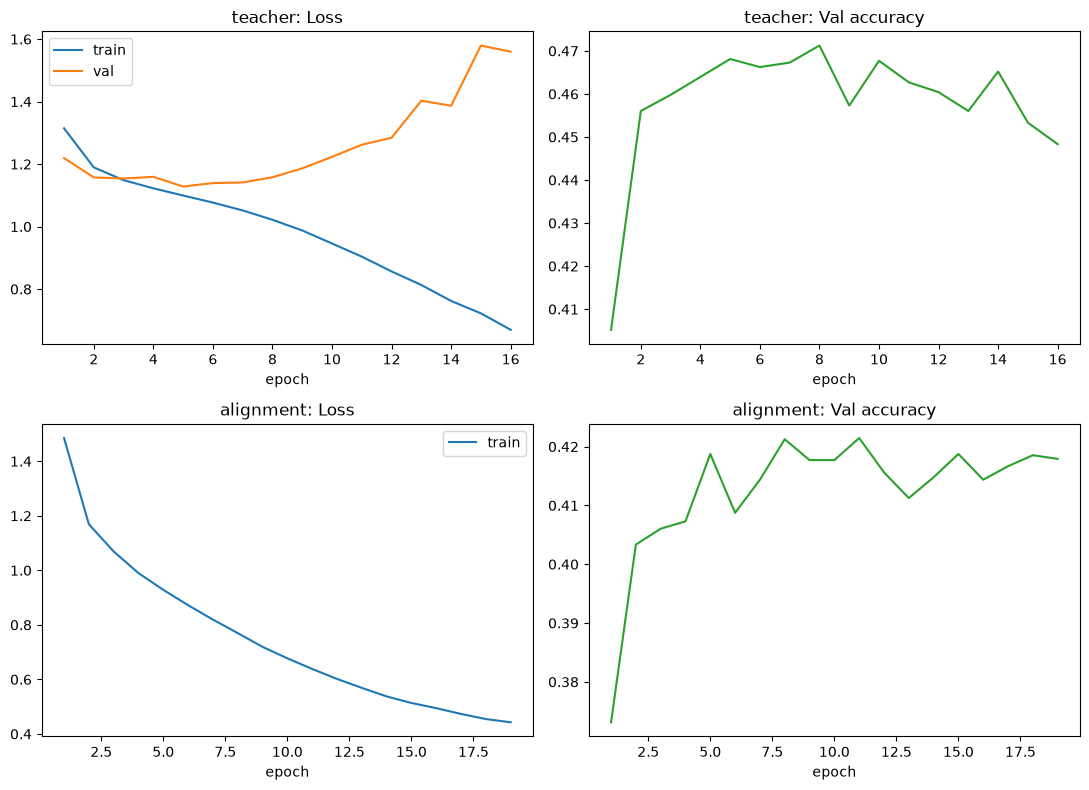

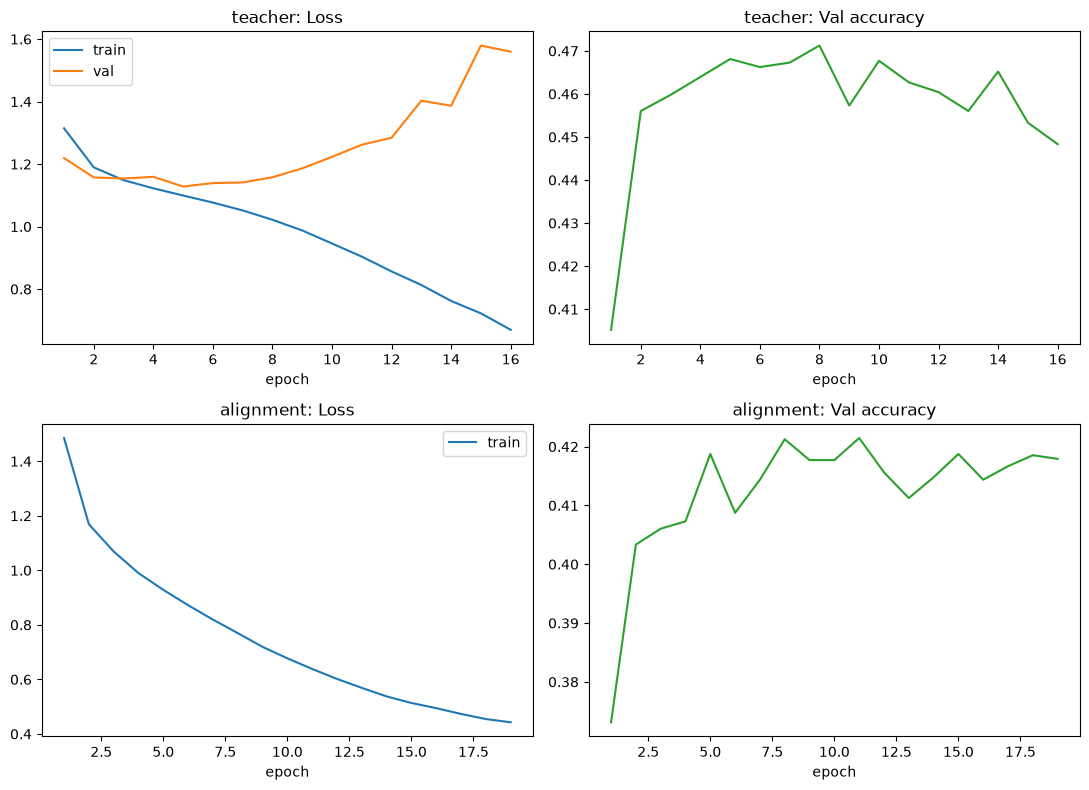

In [18]:
# =====================================================================
# 16. (Optional) loss / metric curves -> Show in Notebook AND save
# =====================================================================
try:
    import matplotlib.pyplot as plt
    from IPython.display import display

    # 1. Ensure inline backend
    %matplotlib inline 
    
    stages = [(s, h) for s, h in RESULTS["history"].items() if h and h.get("train_loss")]
    if stages:
        fig, axes = plt.subplots(len(stages), 2, figsize=(11, 4 * len(stages)), squeeze=False)
        for r, (name, h) in enumerate(stages):
            ep = range(1, len(h["train_loss"]) + 1)
            
            # Loss Plot
            axes[r][0].plot(ep, h["train_loss"], label="train")
            if any(v == v for v in h.get("val_loss", [])):
                axes[r][0].plot(ep, h["val_loss"], label="val")
            axes[r][0].set_title(f"{name}: Loss"); axes[r][0].set_xlabel("epoch"); axes[r][0].legend()
            
            # Metric Plot
            axes[r][1].plot(ep, h.get("val_metric", []), color="tab:green")
            axes[r][1].set_title(f"{name}: Val {h.get('monitor','metric')}"); axes[r][1].set_xlabel("epoch")
        
        fig.tight_layout()
        
        # Save to file
        CURVE_PATH = os.path.join(RUN_DIR, "training_curves.png")
        fig.savefig(CURVE_PATH, dpi=120)
        print(f"Curves saved to: {CURVE_PATH}")
        
        # 2. Force inline display
        display(fig)
        plt.show() 
        plt.close(fig) 
    else:
        print("[plot] No training history to plot (eval_only mode).")
except Exception as e:
    print(f"[plot] Skipped due to error: {e}")